[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/ichristov/intermediate-fluid-mechanics/blob/main/kinematics_material_derivative.ipynb)


# LEARNING OBJECTIVE

After exploring this notebook, you will be able to compute the kinematic quantities associated with a velocity field, as well as acceleration via the material derivative. Symbolic computing tools are used to do the vector calculus. The connections between vectors and tensors and their representations as array and matrices is highlighted.

# PRELIMINARIES

[run the next cell to setup Python environment customizations and load packages]

In [7]:
# interactive plots setup
from ipywidgets import interact, interactive, fixed, interact_manual
import ipywidgets as widgets

# sympy setup
import sympy as sp
sp.init_printing()
from sympy.vector import *

# plotting customizations
from matplotlib import pyplot as plt
size=16
params = {'legend.fontsize': 'large',
#          'figure.figsize': (20,8),
          'axes.labelsize': size,
          'axes.titlesize': size,
          'xtick.labelsize': size*0.875,
          'ytick.labelsize': size*0.875,
          'axes.titlepad': 25}
plt.rcParams.update(params)
%matplotlib inline

# numerics
import numpy as np

# to save plots as files and download them
# from google.colab import files

## Credit

Initial version written by [Ivan C. Christov](http://christov.tmnt-lab.org), Purdue University.

# INTRODUCTION

Inspired by Powers' _Mechanics of Fluids_, Prob. 3.6, consider a two-dimensional Cartesian flow field with velocity vector, $\underline{v} = v_1 \underline{e}_1 + v_2 \underline{e}_2 + v_3 \underline{e}_3$, the components of which are
\begin{align*}
  v_1 &= -c \, x_1 + 4 c \, x_2,\\
  v_2 &= -c \, 4 x_1 - c \, x_2,\\
  v_3 &= 0,
\end{align*}
where $c>0$ is a suitable dimensional constant.

A few other example velocity fields are also set up (commented out) in the cell below where $\underline{v}$ is defined, so you can swap in whichever one you'd like to explore instead:

- A "simple shear flow" (plane Couette-like):
\begin{align*}
  v_1 &= c \, x_2,\\
  v_2 &= 0,\\
  v_3 &= 0.
\end{align*}
- A slightly-less-simple shear flow (plane Poiseuille-like):
\begin{align*}
  v_1 &= c \, (1-x_2^2),\\
  v_2 &= 0,\\
  v_3 &= 0.
\end{align*}
- A "pure-straining flow" (no shear; stagnation-point flow):
\begin{align*}
  v_1 &= c \, x_1,\\
  v_2 &= -c \, x_2,\\
  v_3 &= 0.
\end{align*}

# DEMONSTRATION


We will setup a coordinate system using SymPy's [capabilities](https://docs.sympy.org/latest/modules/vector/fields.html) for our analytical calculations.

In [8]:
from sympy.vector import CoordSys3D, Del
C = CoordSys3D('C')  # C.x, C.y, C.z are the coordinates
# C.i, C.j, C.k are the unit vectors
# define the nabla operator
nabla = Del()

Define the velocity vector in terms of the unit vectors of our coordinate system from SymPy.


In [34]:
c = sp.Symbol('c', positive='True')

v = (-c*C.x + 4*c*C.y) * C.i + (-c*4*C.x - c*C.y) * C.j + 0 * C.k    # Powers' example

# other example velocity fields you could play with:

# v = c*C.y * C.i + 0 * C.j + 0 * C.k                                  # simple shear (Couette)

# v = c*(1-(C.y)**2) * C.i + 0 * C.j + 0 * C.k                         # shear (Poiseuille)

# v = c*C.x * C.i - c*C.y * C.j + 0 * C.k                              # strain (stag. pt.)

print("Velocity field you chose is")
v

Velocity field you chose is


## Velocity field

Before we compute any kinematic quantities, let us just plot the given velocity field as a collection of arrows (called a "[quiver](https://en.wikipedia.org/wiki/Quiver) plot").

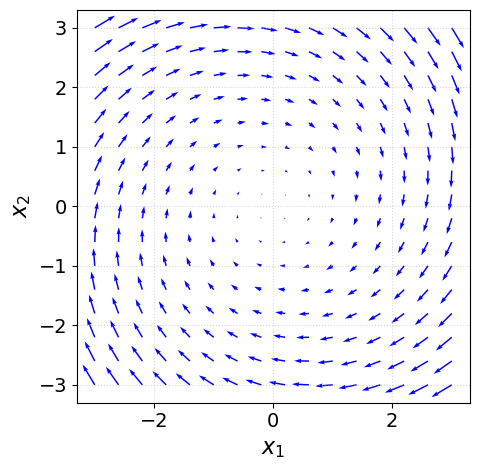

In [ ]:
# simple quiver plot of the chosen velocity field
v_array = [v & C.i, v & C.j, v & C.k]

x1 = np.linspace(-3, 3, 16)
x2 = np.linspace(-3, 3, 16)
X1, X2 = np.meshgrid(x1, x2)

c_val = 1
# 'lambdify' the velocity components to evaluate them numerically
v1_num = sp.lambdify((C.x, C.y), v_array[0].subs(c, c_val), 'numpy')
v2_num = sp.lambdify((C.x, C.y), v_array[1].subs(c, c_val), 'numpy')

U = v1_num(X1, X2)
V = v2_num(X1, X2)

fig, ax = plt.subplots(tight_layout=True)

ax.quiver(X1, X2, U, V, color='blue')

ax.set_xlabel('$x_1$')
ax.set_ylabel('$x_2$')
ax.set_aspect('equal')

ax.grid(alpha=0.5, linestyle='dotted')

## Kinematic quantities and how they are related, $\nabla\underline{v}$

The flow kinematics are determined by the velocity field's gradient, the tensor $\nabla \underline{v}$.

SymPy doesn't have built-in functionality for gradient of a vector (yet). But we can take a [derivative of a vector with respect to a vector](https://docs.sympy.org/latest/modules/tensor/array.html#derivatives-by-array) (like a "Jacobian").

**However**, SymPy, like Panton, calculates $\partial_i v_j$, which most others would term $[\nabla \underline{v}]^t$.

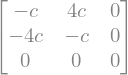

In [36]:
# we need to express the vector via an array of components for the next step
# so, take the dot product of v with each coord vector to get the 3 components
# in SymPy, & is one way to form a dot product
v_array = [v & C.i, v & C.j, v & C.k]

gradv = sp.derive_by_array(v_array, [C.x, C.y, C.z]).transpose()

# convert v and grad v to SymPy matrices
v_array = sp.Matrix(v_array)
gradv = sp.Matrix(gradv)
gradv

The symmetric part, 
$$
    S_{ij} = \partial_{(i}v_{j)} = \frac{1}{2}(\partial_i v_j + \partial_j v_i) = \frac{1}{2}\left([\nabla\underline{v}]^t + \nabla\underline{v}\right),
$$
of the velocity gradient contains information on the shear and extensional motions caused by the velocity field.

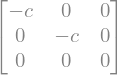

In [37]:
# 1/2 is a float, Rational(1,2) is a symbolic expression for 1/2,
# which lets SymPy do algebra more easily
Sij = sp.Rational(1, 2)*(gradv.transpose() + gradv)
Sij

The shear rate _magnitude_ for the flow is defined using a [double contraction](https://docs.sympy.org/latest/modules/tensor/array.html#products-and-contractions) of $S_{ij}$ with itself. We can implement this operation using some SymPy functions.

In [38]:
SS = sp.sqrt(sp.tensorcontraction(sp.tensorcontraction(sp.tensorproduct(Sij, Sij), (1, 2)), (0, 1)))
SS.simplify()

The anti-symmetric part, 
$$
    \Omega_{ij} = \partial_{[i}v_{j]} = \frac{1}{2}(\partial_i v_j - \partial_j v_i) = \frac{1}{2}\left([\nabla\underline{v}]^t - \nabla\underline{v}\right),
$$
of the velocity gradient contains information about rotational motions caused by the velocity field.

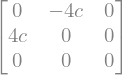

In [39]:
Omegaij = sp.Rational(1, 2)*(gradv.transpose() - gradv)
Omegaij

Finally, we verify that the kinematic decomposition, $\partial_i v_j = S_{ij} + \Omega_{ij}$, works.

In [40]:
gradv.transpose() == Sij + Omegaij

True

## Visualizing the deformation of a fluid element

$S_{ij}$ and $\Omega_{ij}$, computed above, are exactly what govern how a small fluid element deforms as it is advected by a flow. 

We can see this directly: release a handful of tracer points forming a small square element (corners $A,D,C,B$) together with its inscribed diamond (edge midpoints $A_{1/2},D_{1/2},C_{1/2},B_{1/2}$), follow their trajectories under whichever velocity field $\underline{v}$ we defined above, and plot where they end up.

In [41]:
from scipy.integrate import solve_ivp

# substitute a definite numeric value for the (otherwise symbolic) constant c,
# purely for this numerical/visual demonstration
c_val = 1
v1_num = sp.lambdify((C.x, C.y), v_array[0].subs(c, c_val), 'numpy')
v2_num = sp.lambdify((C.x, C.y), v_array[1].subs(c, c_val), 'numpy')

def rhs(t, x):
    return [v1_num(x[0], x[1]), v2_num(x[0], x[1])]

# undeformed square element ABCD (corners) with its inscribed diamond
# (edge midpoints A_{1/2}, D_{1/2}, C_{1/2}, B_{1/2}), centered at the
# origin with side length h
h = 1.0
pts0 = {
    'A': (-h/2,  h/2), 'A_{1/2}': ( 0.0,  h/2), 'D': ( h/2,  h/2),
    'B_{1/2}': (-h/2,  0.0),                    'D_{1/2}': ( h/2,  0.0),
    'B': (-h/2, -h/2), 'C_{1/2}': ( 0.0, -h/2), 'C': ( h/2, -h/2),
}
square_order = ['A', 'D', 'C', 'B', 'A']
diamond_order = ['A_{1/2}', 'D_{1/2}', 'C_{1/2}', 'B_{1/2}', 'A_{1/2}']

# integrate each tracer point's trajectory once; interpolate at any t afterwards
Tmax = 2.0
sols = {lbl: solve_ivp(rhs, (0, Tmax), xy0, dense_output=True, rtol=1e-8, atol=1e-8)
        for lbl, xy0 in pts0.items()}

def polygon_area(coords):
    # shoelace formula for a simple polygon given as a list of (x, y) points
    x, y = zip(*coords)
    n = len(x)
    return 0.5*abs(sum(x[i]*y[(i+1) % n] - x[(i+1) % n]*y[i] for i in range(n)))

def plot_func(t, save=False):
    pos = {lbl: sol.sol(t) for lbl, sol in sols.items()}
    area = polygon_area([pos[l] for l in ['A', 'D', 'C', 'B']])

    fig, ax = plt.subplots(tight_layout=True)
    ax.set_xlabel('$x_1$')
    ax.set_ylabel('$x_2$')
    ax.set_aspect('equal')

    # undeformed element, for reference
    ax.plot([pts0[l][0] for l in square_order], [pts0[l][1] for l in square_order],
            color='gray', linewidth=1, linestyle='dashed', label='$t=0$')
    ax.plot([pts0[l][0] for l in diamond_order], [pts0[l][1] for l in diamond_order],
            color='gray', linewidth=1, linestyle='dashed')

    # deformed element at time t
    ax.plot([pos[l][0] for l in square_order], [pos[l][1] for l in square_order],
            color='darkred', linewidth=2, label=f'$t={t:.2f}$')
    ax.plot([pos[l][0] for l in diamond_order], [pos[l][1] for l in diamond_order],
            color='darkred', linewidth=2)

    for l in pts0:
        ax.annotate(f"${l}'$", pos[l], xytext=(5, 5), textcoords='offset points',
                    color='darkred',
                    bbox=dict(boxstyle='round,pad=0.15', facecolor='white', alpha=0.8, edgecolor='none'))

    # subtle area indicator, styled to match the legend's frame
    ax.text(0.98, 0.02, f'Area $= {area:.3f}$',
            transform=ax.transAxes, ha='right', va='bottom',
            bbox=dict(boxstyle='round', facecolor='white', alpha=0.8, edgecolor='0.8'))

    ax.grid(alpha=0.5, linestyle='dotted')
    ax.legend(loc='upper left')

    if save:
        fig.savefig(save)

    plt.show()

First, a static plot at one value of time $t$, to see that it works.

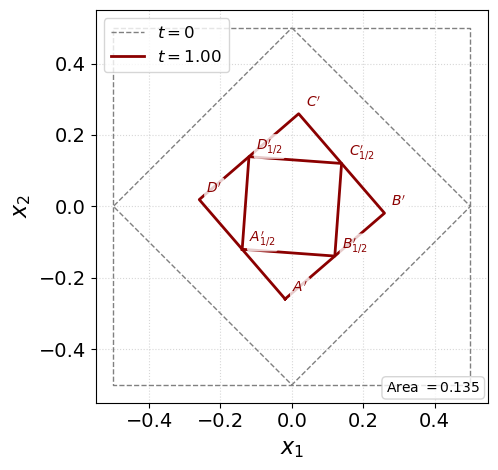

In [42]:
plot_func(1.0)

Then, an `interact` widget lets us vary $t$ to see the element deform continuously as it is advected by the flow.

In [43]:
interact(plot_func,
         t = widgets.FloatSlider(value=0.0, min=0.0, max=Tmax, step=0.05, description='time, t'),
         save=fixed(False));

**On your own:** the displayed area is computed purely numerically, from the tracked corner positions. See if you can derive a theoretical formula for it in terms of $t$ and $\nabla\cdot\underline{v}$ (computed in the next section). Then, check it against the numbers shown above as you move the slider.

This reproduces the classic square-into-parallelogram cartoon used in textbooks to motivate $S_{ij}$ and $\Omega_{ij}$ in the first place (except here it is computed directly from $\underline{v}$, for whichever flow you have chosen, rather than drawn by hand).

## Divergence, $\nabla\cdot\underline{v}$

The divergence, $\nabla\cdot\underline{v}$, of the vector field $\underline{v}$ gives the local flux. It can also be related to average rate of expansion caused by the flow.

To determine whether the flow field is locally expanding or compressing fluied elements, we compute the divergence  and check if it is nonzero.

In [44]:
divv = (nabla & v).doit()
divv = sp.simplify(divv)
divv

If $\nabla\cdot\underline{v}=0$, then the flow has no local volume expansion, that is, it is an incompressible _flow_. Otherwise, fluid elements change volume under the action of this flow (check it in the plots above). 

We can also verify the identity that $\nabla\cdot\underline{v} = \partial_i v_i = S_{ii} = \mathrm{tr}\underline{\underline{S}}$.

In [45]:
divv == sp.trace(Sij)

True

## Curl, $\nabla\times\underline{v}$

The curl, $\nabla\times\underline{v}$, of the vector field $\underline{v}$ gives the local spin rate. We call it the _vorticity_ $\underline{\omega}$.

To determine whether the flow field is locally rotational or irrotational, we compute the vorticity vector and check if it has nonzero components.

In [46]:
# general expression
# in SymPy ^ is one way to denote a cross product
vorticity = (nabla ^ v).doit()
# (also used in some books), instead of \times

# evaluated expression
vorticity

To drive the point about $\Omega_{ij}$ home, we compute the _dual vector_ $d_k$ of $\Omega_{ij}$ from the definition given in Panton's Eq. (3.7.4), namely $d_k = \epsilon_{kij}\Omega_{ij}$.

We could use fancy double contraction operations (but I had a hard time figuring it out in the context of $\epsilon_{ijk}$ in SymPy).

So let's brute-force it with some loops.

In [47]:
# initialize d_k as a zero matrix
dvec = sp.Matrix.zeros(3, 1)

for k in 1, 2, 3:
    dvec[k-1] = 0
    for i in 1, 2, 3:
        for j in 1, 2, 3:
            # LeviCivita is 1-indexed, Python arrays are 0-indexed :)
            dvec[k-1] += sp.LeviCivita(k, i, j)*Omegaij[i-1, j-1]

d = dvec[0] * C.i + dvec[1] * C.j + dvec[2] * C.k
d

And, we verify that $d_k = \omega_k$ is the precisely the vorticity vector.

In [48]:
d == vorticity

True

Vice, versa, we can also check that the rate of rotation tensor can be built from the vorticity vector as $\Omega_{ij} = \frac{1}{2}\epsilon_{ijk} \omega_k$.

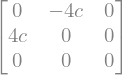

In [49]:
Omegaij_from_w = sp.Matrix.zeros(3, 3)

for i in 1, 2, 3:
    for j in 1, 2, 3:
        for k in 1, 2, 3:
            # LeviCivita is 1-indexed, Python arrays are 0-indexed :)
            Omegaij_from_w[i-1,j-1] += sp.Rational(1, 2)*sp.LeviCivita(i, j, k) \
                                        *vorticity.to_matrix(C)[k-1]

Omegaij_from_w

In [50]:
Omegaij_from_w == Omegaij

True

## Acceleration, the material derivative of the velocity


The Eulerian acceleration vector, $\underline{a}$, at a point in space is found using the material derivative
$$
   \underline{a} = \frac{D\underline{v}}{Dt} = \partial_t \underline{v} + (\underline{v}\cdot\nabla)\underline{v}.
$$
The chosen flow is steady, so $\partial_t \underline{v} = \underline{0}$ and we have only convective acceleration.

First, we compute the convective acceleration using the directional derivative interpretation as 
$$
    v_j\partial_j v_i = (v_j\partial_j)v_i = (\underline{v}\cdot\nabla)\underline{v}
$$
and [SymPy vector calculus](https://docs.sympy.org/latest/modules/vector/fields.html#directional-derivative).

In [51]:
# in SymPy, & is one way to form a dot product
vdotgradv = (v & nabla)(v)
vdotgradv = sp.simplify(vdotgradv)
vdotgradv

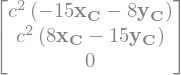

In [52]:
# reprint it as a vertical array for easier reading
vdotgradv_array = sp.Matrix([[vdotgradv & C.i], [vdotgradv & C.j], [vdotgradv & C.k]])
vdotgradv_array = sp.simplify(vdotgradv_array)
vdotgradv_array

Second, we compute the convective acceleration using the matrix-vector product interpretation as $ v_j \partial_j v_i = (\partial_j v_i)v_j = [\nabla\underline{v}] \underline{v}$.

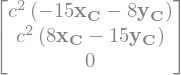

In [53]:
sp.simplify(gradv * v_array)

We verify the first and second methods agree.

In [54]:
vdotgradv_array == sp.simplify(gradv * v_array)

True

With some index notation magic, we could also compute the same term as $\underline{v}[\nabla \underline{v}]^t$, considering $\underline{v}$ as a _row_ vector now. 

A lot of transposes follow...

In [55]:
sp.simplify(v_array.transpose() * gradv.transpose())

In [56]:
vdotgradv_array == sp.simplify(v_array.transpose() * gradv.transpose()).transpose()

True